In [1]:
# TASK C - Import libraries 

import random 
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 

%matplotlib inline

In [3]:
# change working diretory 
os.chdir(r"/Users/f/downloads")
data = pd.read_csv('Unit06 weatherAUS.csv')

In [4]:
data.head()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No


In [5]:
print(data.columns)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')


In [9]:
# RainToday and RainTomorrow dropped here since it is categorical data 
df = data.drop(columns=['RainToday', 'RainTomorrow'])
df.head()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7


In [10]:
# normalising over the standard deviation

from sklearn.preprocessing import StandardScaler
X = df.values[:,1:]
X = np.nan_to_num(X)
Clus_dataSet = StandardScaler().fit_transform(X)
Clus_dataSet


array([[-0.01620475, -0.20358073,  0.40779566, ...,  0.31297023,
         0.01724645,  0.08573194],
       [ 0.28078019, -0.27509664,  0.40779566, ...,  0.31523499,
         0.06193983,  0.41315549],
       [ 0.36177609, -0.27509664,  0.5279215 , ...,  0.31814683,
         0.6280559 ,  0.26908913],
       ...,
       [ 0.52376787, -0.27509664, -0.01264476, ...,  0.34435335,
        -0.63825637,  0.64890045],
       [ 0.53726719, -0.27509664, -0.55321102, ...,  0.34338274,
        -0.25091379,  0.63580351],
       [-3.10754799, -0.27509664, -2.23497271, ...,  0.34791227,
        -0.26581159, -0.03214054]], shape=(145460, 11))

In [11]:
# setting value for k to 3

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=12,
    max_iter=300,
    random_state=42
)

kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,12
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [13]:
# pairing the features for plotting 

feature_pairs = [
    ('MinTemp', 'MaxTemp'),
    ('Humidity9am', 'Humidity3pm'),
    ('Pressure9am', 'Pressure3pm'),
    ('WindSpeed9am', 'WindSpeed3pm'),
    ('Temp9am', 'Temp3pm')
]

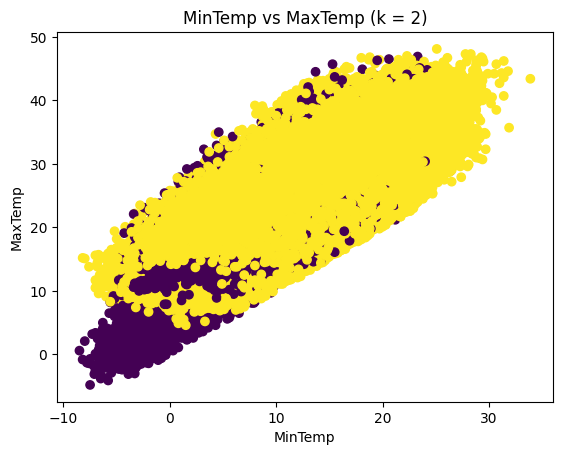

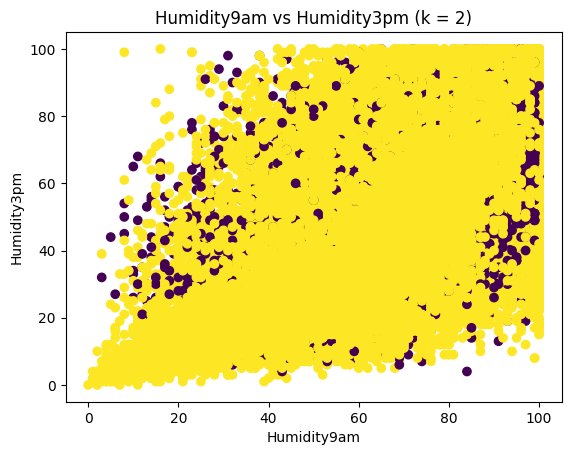

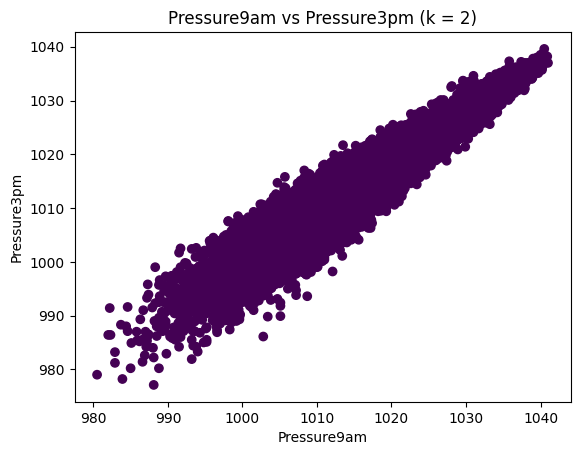

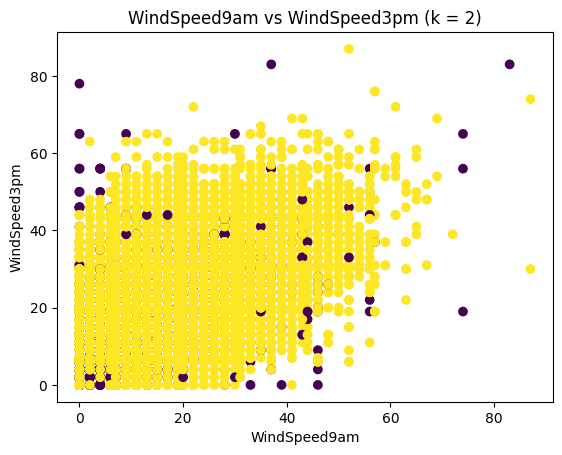

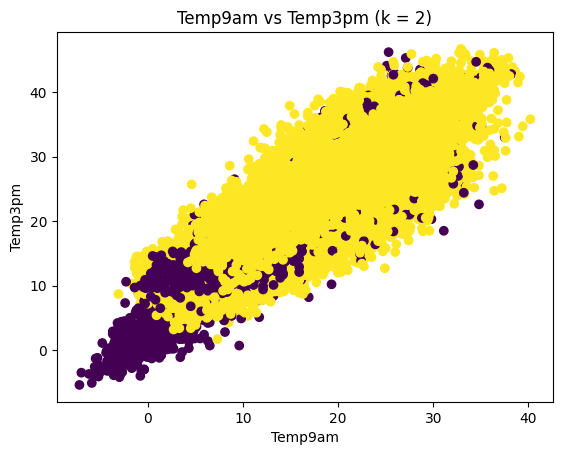

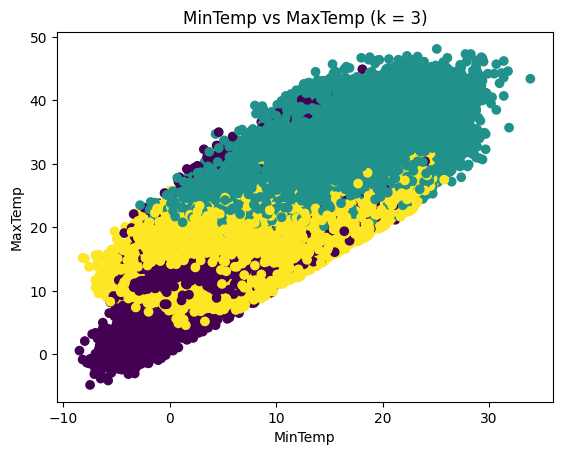

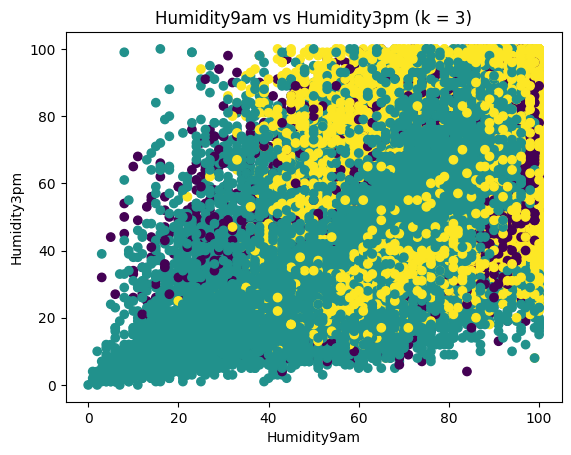

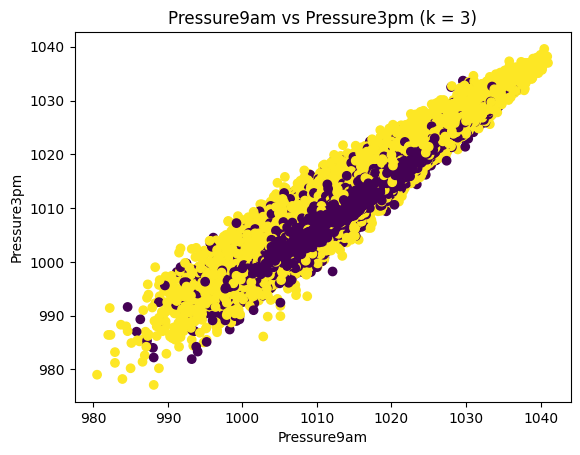

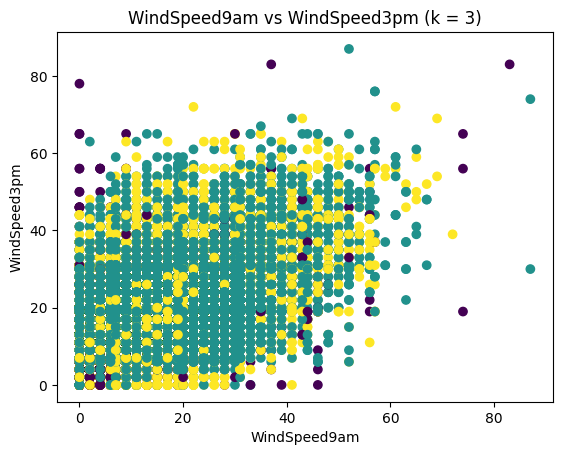

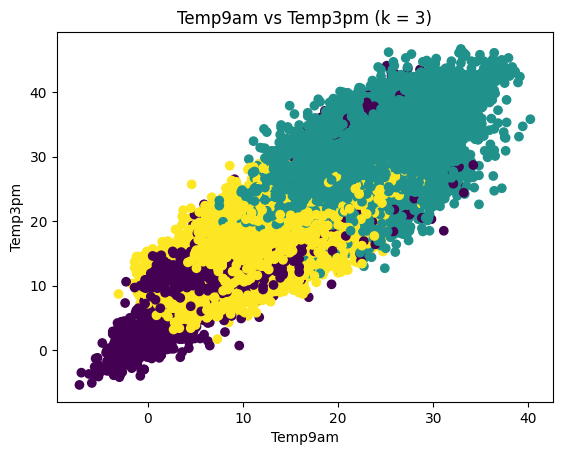

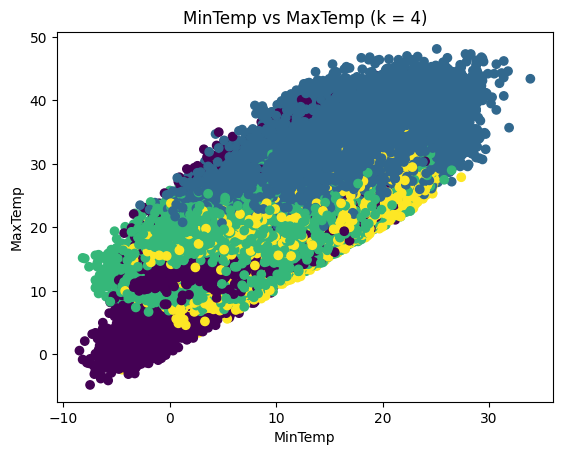

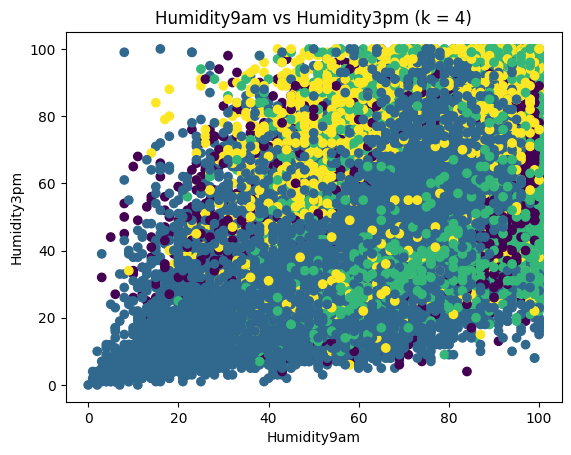

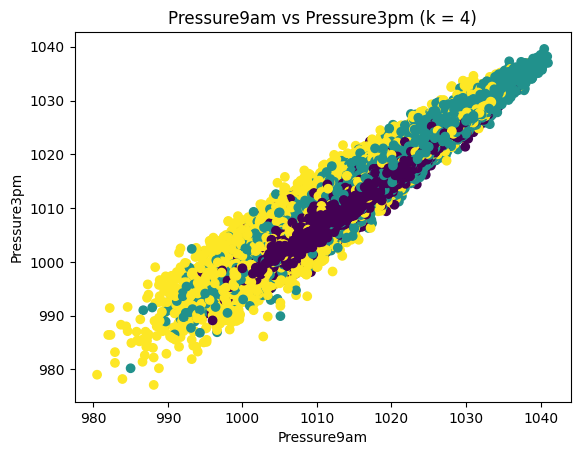

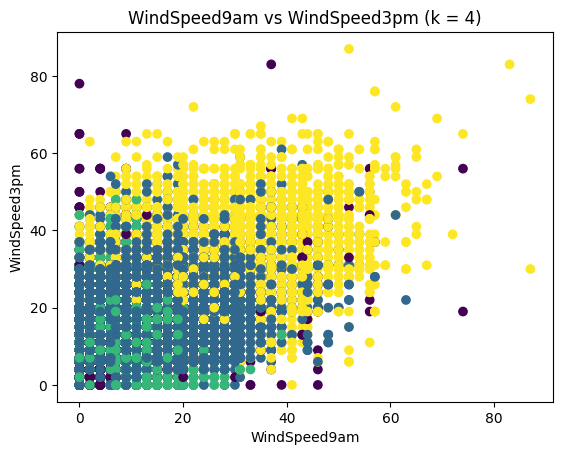

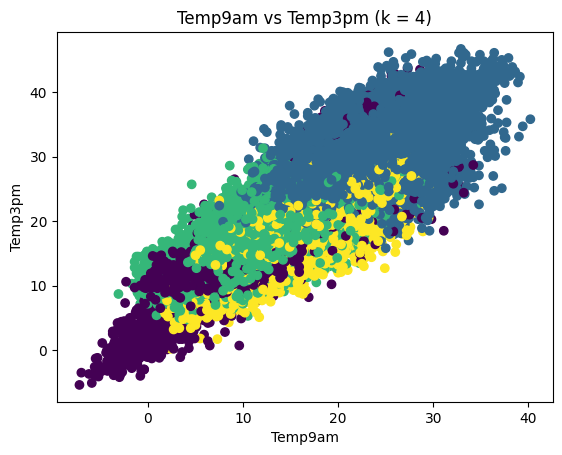

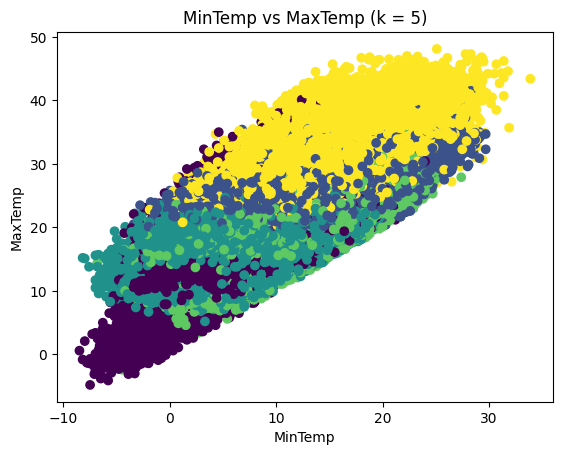

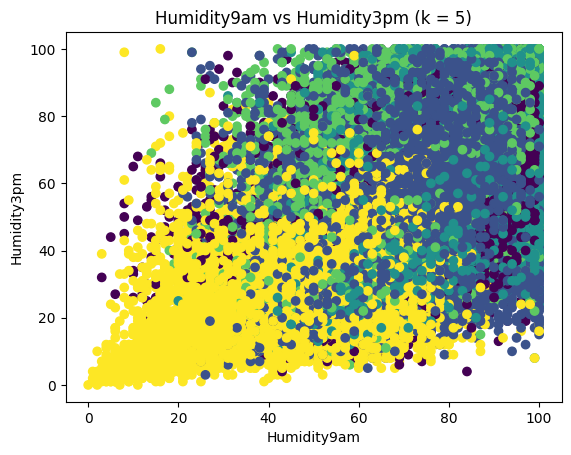

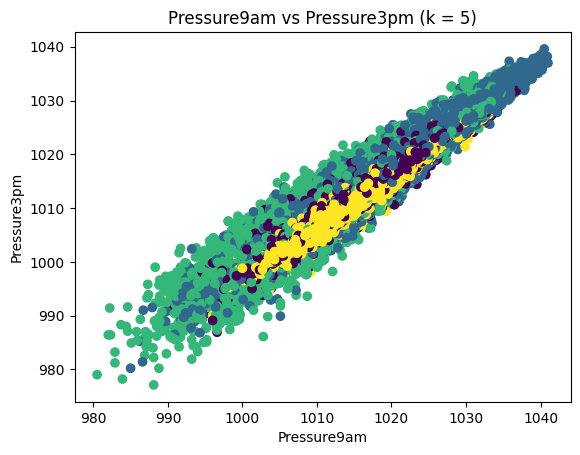

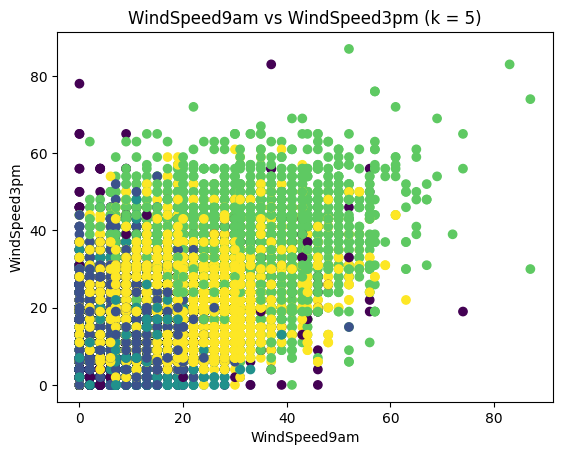

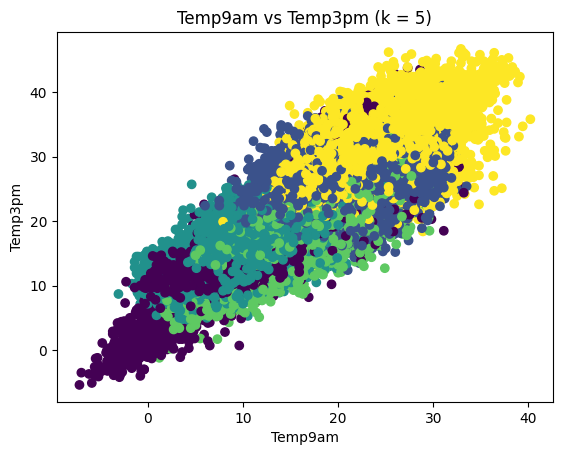

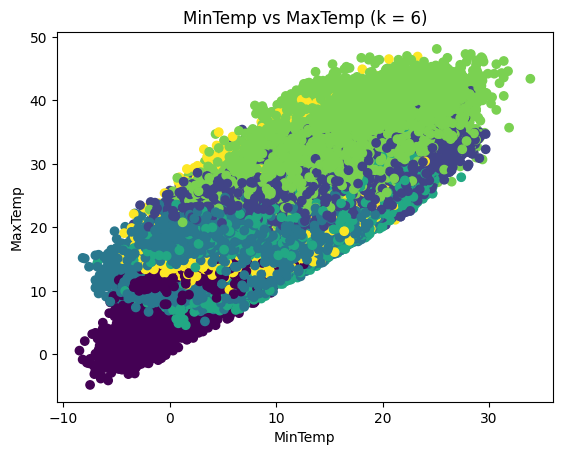

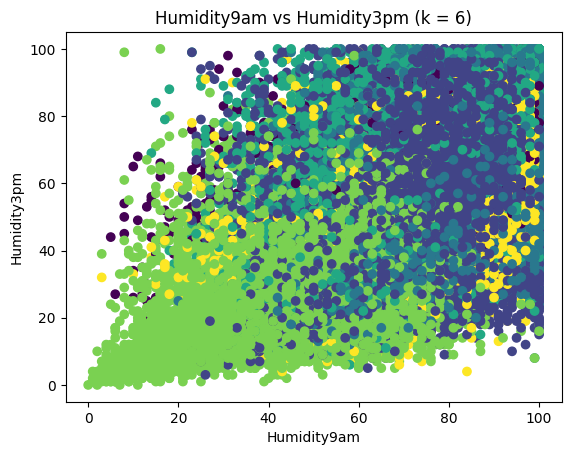

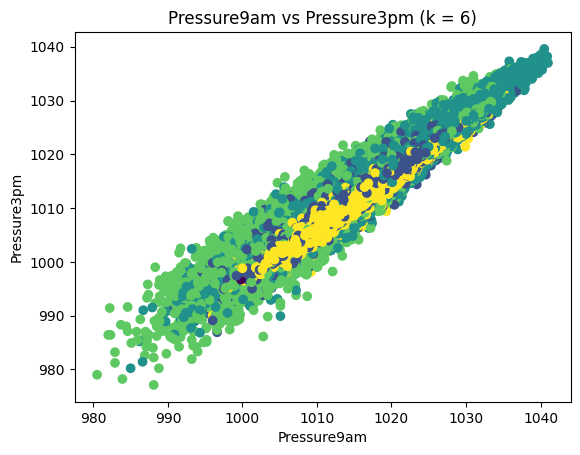

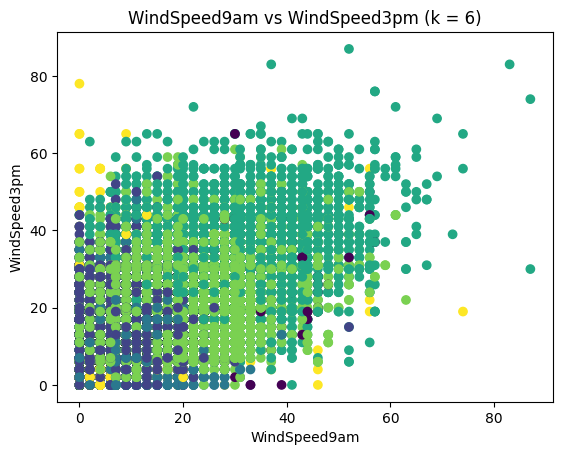

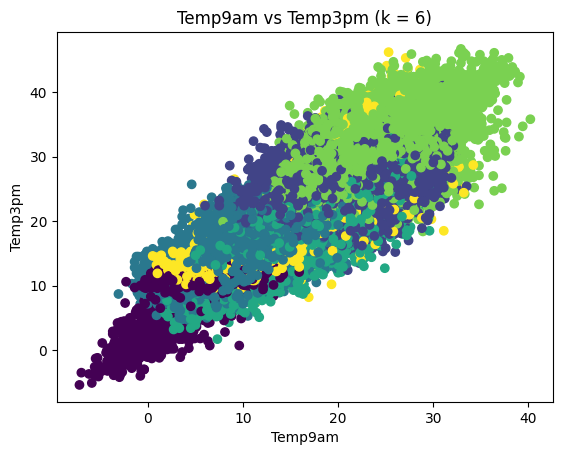

In [15]:
from sklearn.cluster import KMeans

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(Clus_dataSet)

    for x_col, y_col in feature_pairs:
        plt.figure()
        plt.scatter(df[x_col], df[y_col], c=labels)
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{x_col} vs {y_col} (k = {k})")
        plt.show()

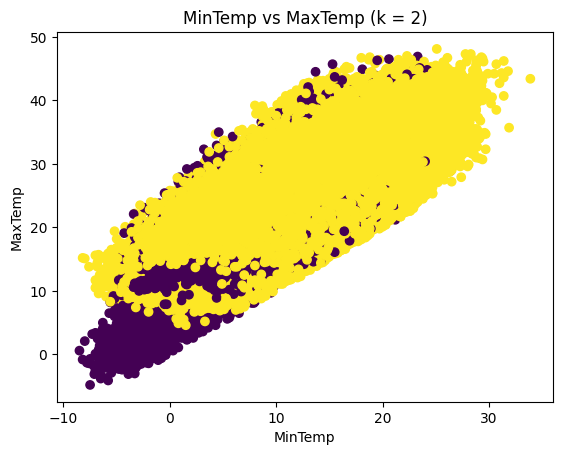

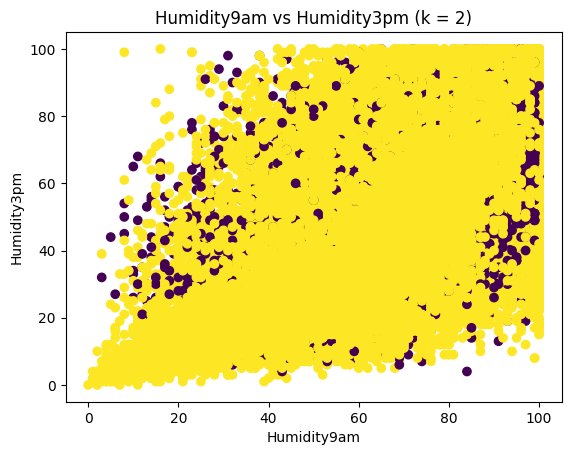

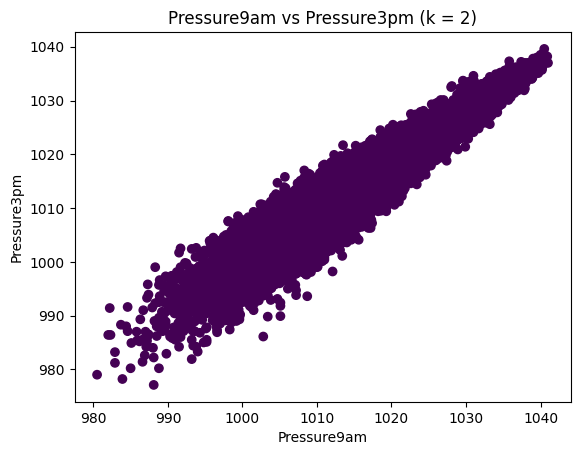

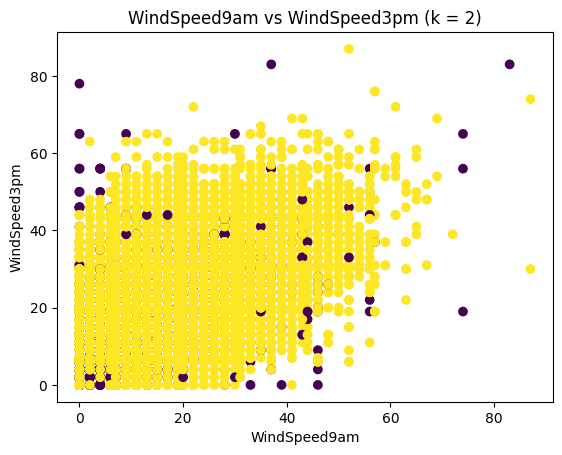

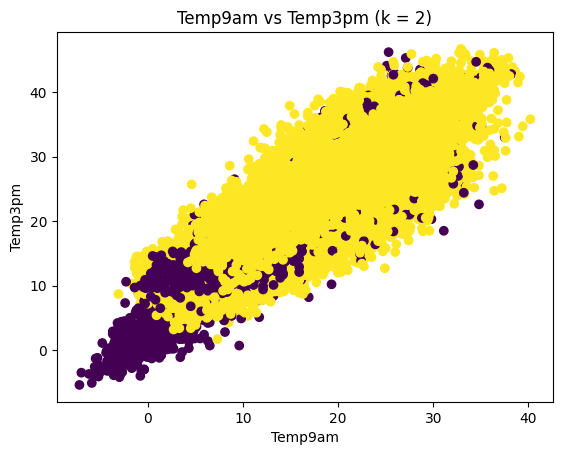

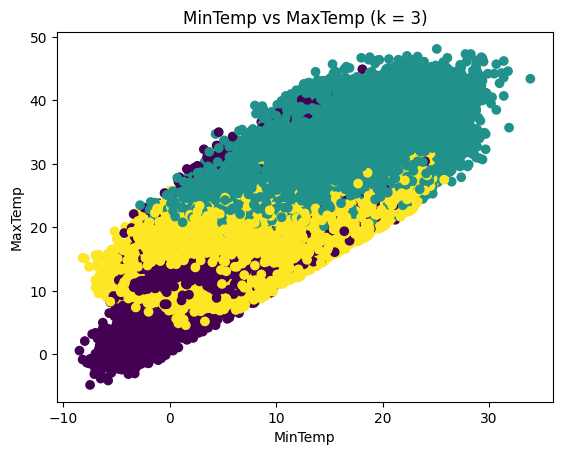

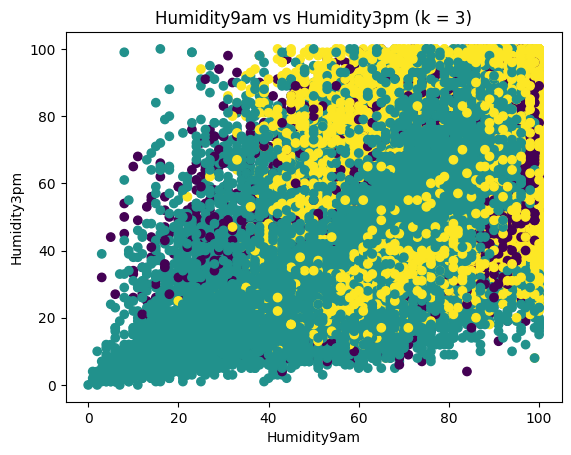

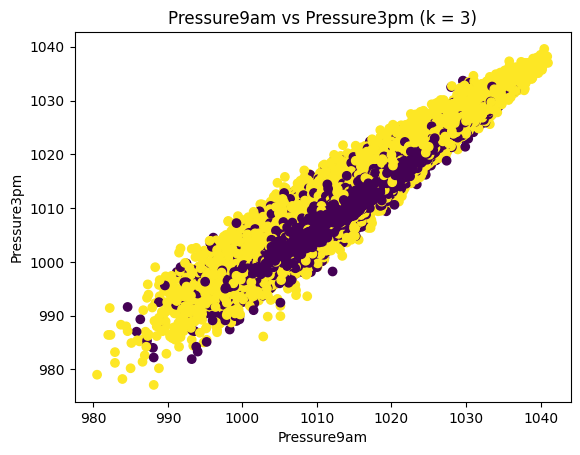

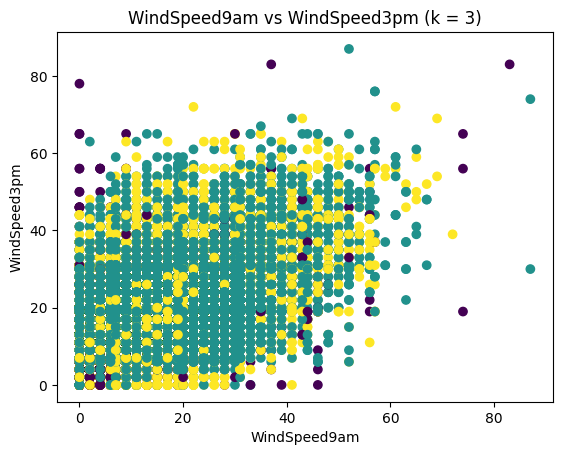

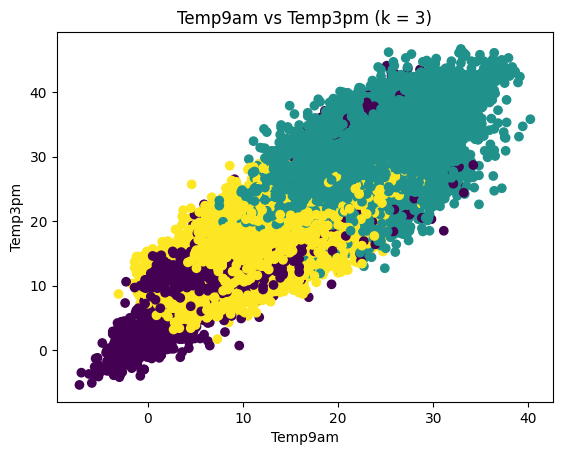

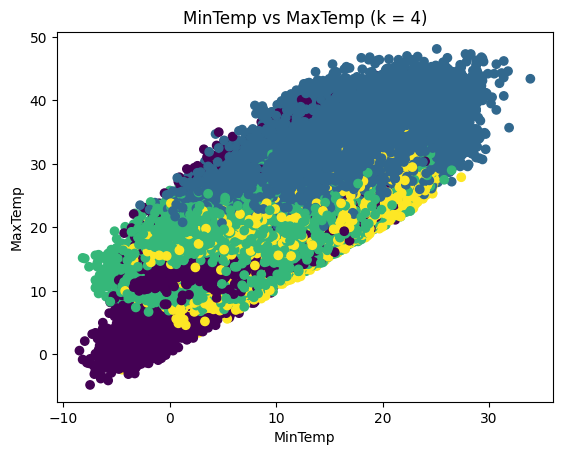

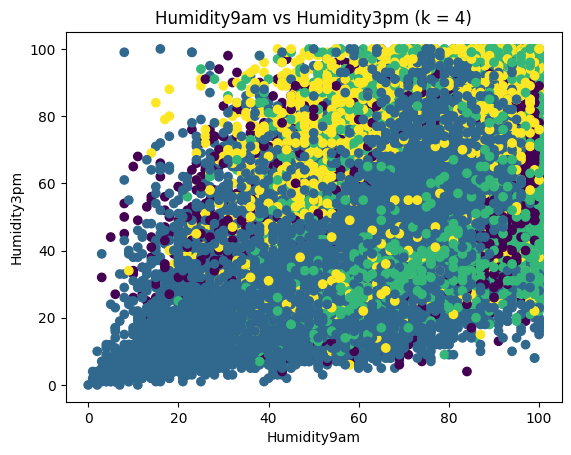

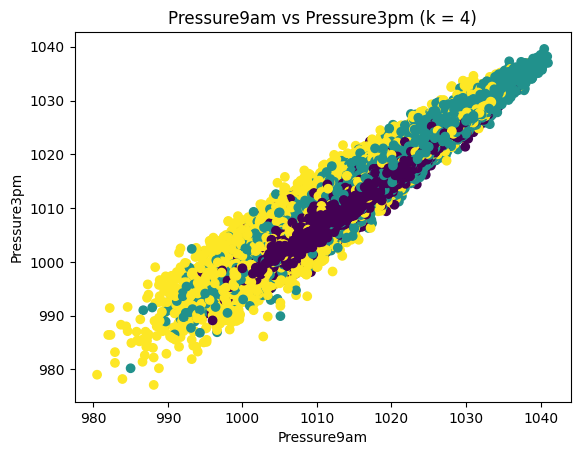

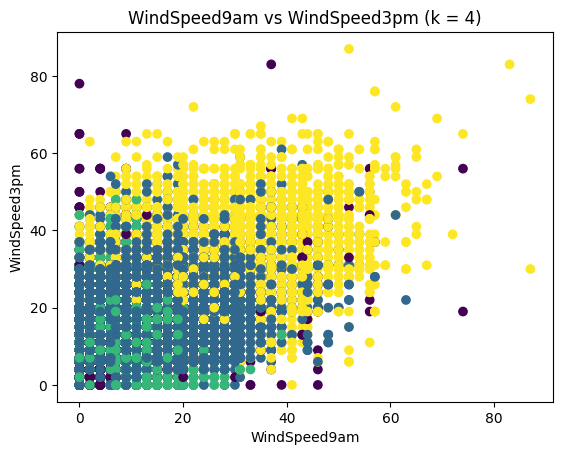

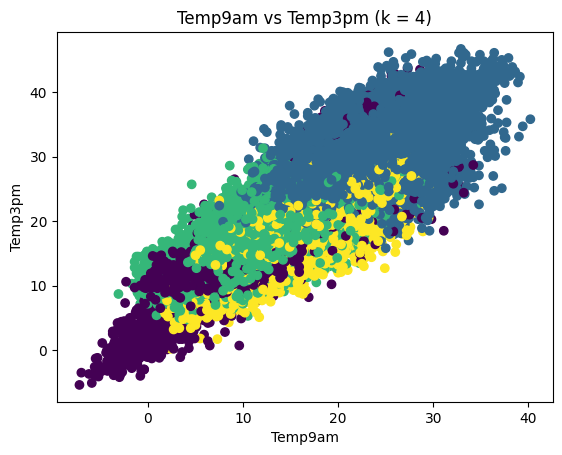

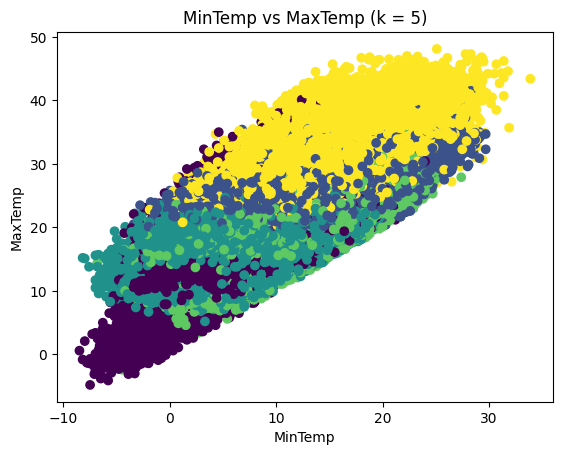

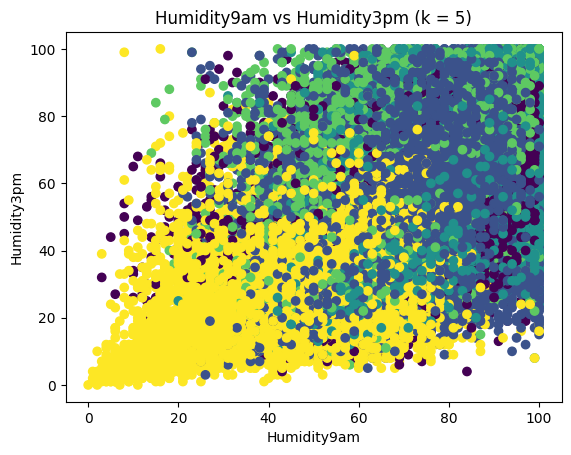

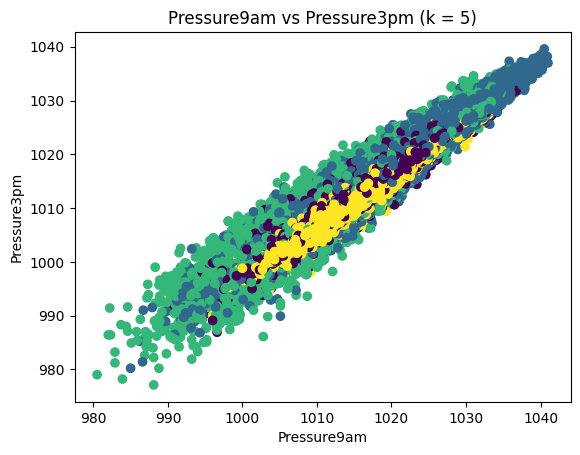

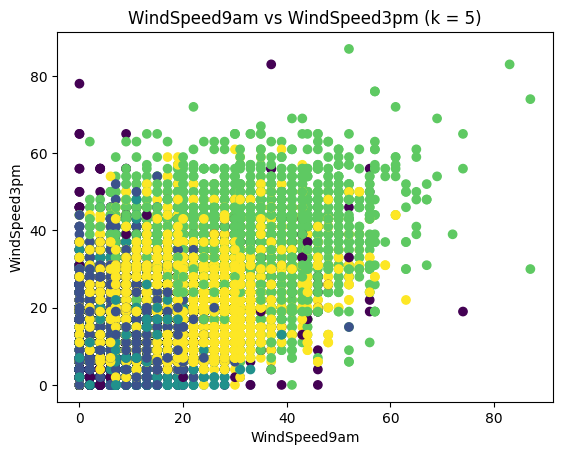

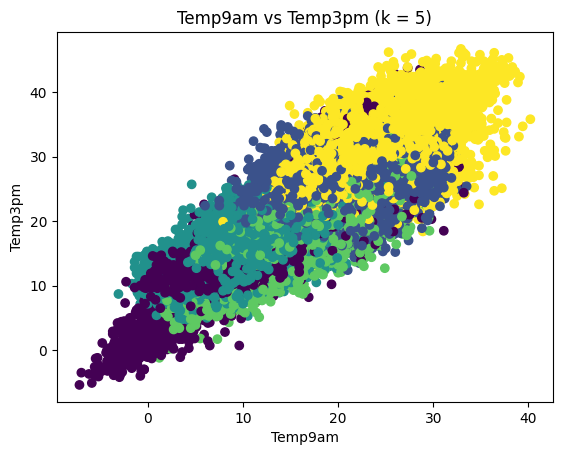

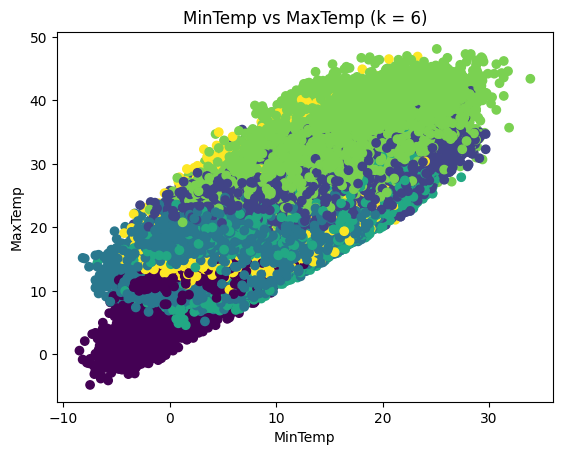

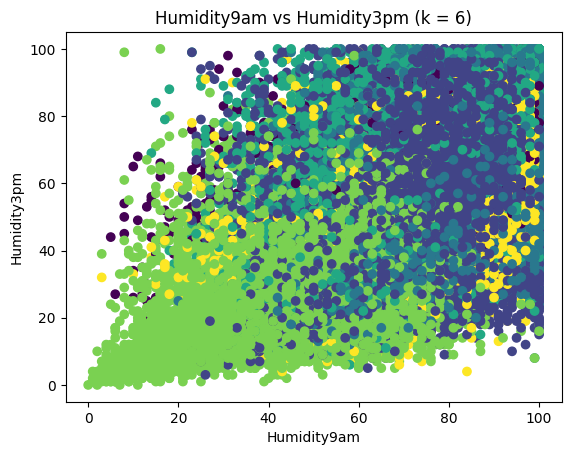

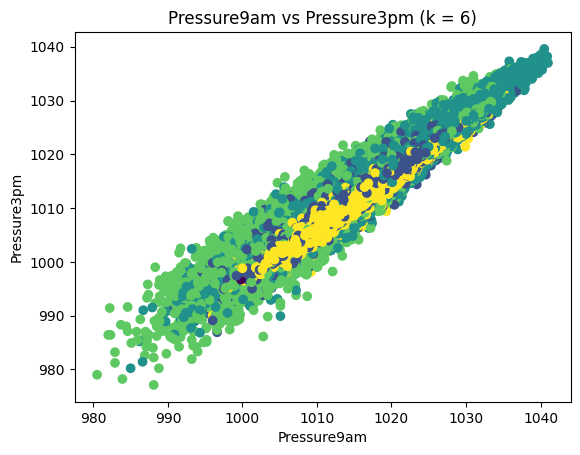

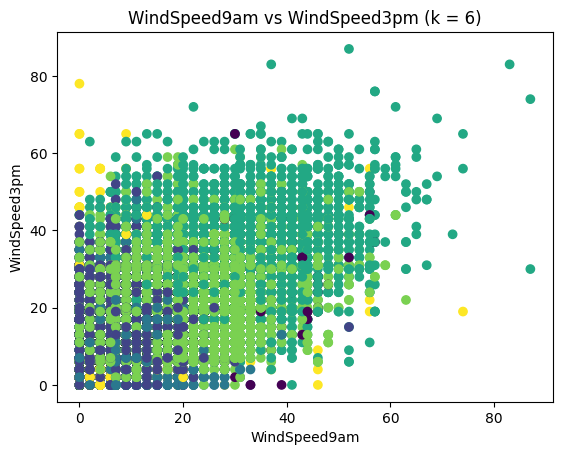

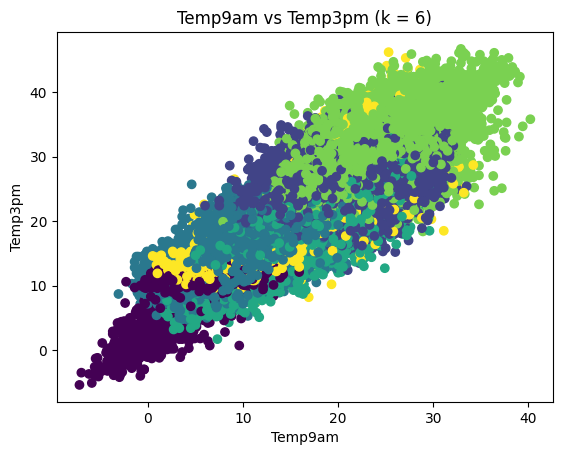

In [15]:
from sklearn.cluster import KMeans

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(Clus_dataSet)

    for x_col, y_col in feature_pairs:
        plt.figure()
        plt.scatter(df[x_col], df[y_col], c=labels)
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{x_col} vs {y_col} (k = {k})")
        plt.show()